## 1. Setup Notebook

**Model configuration**
- Select `.yaml` file defining model, solver, and outputs  
- All configs are located in `Automation/configs/`  
- Add new models by extending the `MODEL_TO_CONFIG` dictionary  

**Run modes**
- `"run_missing"`: run only simulations without existing `run_summary.json`  
- `"overwrite"`: rerun all simulations (ignore existing results)  
- `"load_only"`: load existing summaries only (no simulations executed)  

**Parallelization (`workers`)**
- Number of simulations executed in parallel (separate processes)  
- Not a direct core assignment, but effectively controls CPU usage  
- Guideline: use ~60–80% of available CPU cores  
  - Example: 12-core machine → 8–10 workers is typically optimal
 
**Repository setup**
- Detects and sets the repository root path  
- Adds repo root to `sys.path` for module imports  
- Prints: `.../Automation_main` 

In [3]:
# -------------------------
# INPUT (edit only here)
# -------------------------

# Model selection: (must exist in MODEL_TO_CONFIG below)
MODEL = "Dupi"

# Run modes:
MODE = "run_missing"

# Parallelization: Number of parallel workers
workers = 8  


# -------------------------
# IMPORTS
# -------------------------

import sys, json
from pathlib import Path
import numpy as np
import pandas as pandas 
import h5py
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import importlib


# -------------------------
# Resolve repository root
# -------------------------

# If running from /notebooks, go one level up
# Otherwise assume current working directory is repo root
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Adds repo root to Python path so imports like `scripts.runner` work
sys.path.insert(0, str(repo_root))

print("repo_root:", repo_root)


# -------------------------
# Model → config mapping
# -------------------------

# Maps model names to their YAML configuration files
MODEL_TO_CONFIG = {
    "Kapitanov": repo_root / "configs" / "Kapitanov_sweep.yaml",
    "Walz": repo_root / "configs" / "Walz_sweep.yaml",
    "Tiraboschi": repo_root / "configs" / "Tiraboschi_sweep.yaml",
    "Lebri": repo_root / "configs" / "Lebri_sweep.yaml",
    "Dupi": repo_root / "configs" / "Dupi_sweep.yaml",
}

# Resolve selected config
config_path = MODEL_TO_CONFIG[MODEL]
print("Using config:", config_path)

from scripts.runner import (
    load_config,
    _effective_params,
    run_timecourse_reference,
)

repo_root: C:\Users\LevinSchöpfer\Automation_main
Using config: C:\Users\LevinSchöpfer\Automation_main\configs\Dupi_sweep.yaml


## Timecourse simulation setup

This cell defines the simulation settings and either runs or loads the requested timecourse simulations.

### Input variables

- **`T_END_MODE`**  
  Defines whether the simulation is run as:
  - `"SS"` = steady state mode  
    Uses **25 doses** and interprets `time_weeks` as the **dosing interval**
  - `"SD"` = single dose mode  
    Uses **1 dose** and interprets `time_weeks` as the **simulation horizon**

- **`time_weeks`**  
  Number of weeks used in the run:
  - in **SS mode**: dosing interval in weeks
  - in **SD mode**: total simulated time in weeks

- **`dose_mgkg`**  
  Dose level(s) in mg/kg.  
  Can be either:
  - a single value, e.g. `1`
  - a list of values, e.g. `[1, 2, 5]`

- **`param_overrides`**  
  Dictionary of parameter values that should temporarily overwrite the YAML/model defaults.  
  Example:
  ```python
  param_overrides = {"Cl_ml_day": 45}

In [4]:
# -------------------------
# INPUT (edit only here)
# -------------------------


# Simulation mode:
T_END_MODE = "SS"


# Time in weeks:
time_weeks = 2  # SS: dosing interval; SD: simulation horizon


# Dose(s) in mg/kg:
dose_mgkg = [1, 2, 5]


# Optional parameter overrides:
param_overrides = {
} 


# -------------------------
# VALIDATION / TARGETS
# -------------------------

if T_END_MODE not in ("SS", "SD"):
    raise ValueError("T_END_MODE must be either 'SS' or 'SD'.")

# Convert dose input into a standardized list of floats
if isinstance(dose_mgkg, (list, tuple)):
    dose_list = [float(d) for d in dose_mgkg]
else:
    dose_list = [float(dose_mgkg)]

if not dose_list:
    raise ValueError("dose_mgkg must contain at least one dose.")

if time_weeks <= 0:
    raise ValueError("time_weeks must be > 0.")

# -------------------------
# DEFINE RUN SETTINGS BASED ON MODE
# -------------------------

if T_END_MODE == "SS":
    n_doses_override = 25
    pk_only = False
elif T_END_MODE == "SD":
    n_doses_override = 1
    pk_only = False  # keep PD output behavior consistent with SS

# Create one run target per dose
# Each target is a tuple: (dose_mgkg, interval_or_horizon_weeks)
targets = [(dose, int(time_weeks)) for dose in dose_list]

# Show summary of requested run setup
print("Run settings")
print("------------")
print(f"Mode:           {T_END_MODE}")
print(f"Time (weeks):   {time_weeks}")
print(f"Dose(s) mg/kg:  {dose_list}")
print(f"Overrides:      {param_overrides if param_overrides else 'None'}")

# -------------------------
# LOAD MODEL CONFIGURATION
# -------------------------

cfg = load_config(config_path)

# Import model module defined in the YAML config
model_module = importlib.import_module(cfg["model"]["module"])

# Resolve effective parameters:
# DEFAULTS + YAML params + manual overrides
effective_params = _effective_params(cfg, model_module, param_overrides)

# -------------------------
# RUN / LOAD TIMECOURSE SIMULATIONS
# -------------------------

runs = []
for d, pw in targets:
    if MODE in ("run_missing", "overwrite"):
        summary = run_timecourse_reference(
            config_path=config_path,
            dose_mgkg=d,
            interval_weeks=pw,
            param_overrides=param_overrides,
            n_doses_override=n_doses_override,
            pk_only=pk_only,
            overwrite=(MODE == "overwrite"),
        )
        run_dir = Path(summary["_run_dir"])
    else:
        raise RuntimeError("For now, please use MODE='run_missing' or 'overwrite' for this notebook.")

    runs.append({
        "dose_mgkg": d,
        "time_weeks": pw,
        "run_dir": run_dir,
        "summary": summary,
    })

# -------------------------
# DISPLAY PREPARED RUNS
# -------------------------

print("\nPrepared runs")
print("-------------")
for run in runs:
    print(f"dose = {run['dose_mgkg']}")

Run settings
------------
Mode:           SS
Time (weeks):   2
Dose(s) mg/kg:  [1.0, 2.0, 5.0]
Overrides:      None

Prepared runs
-------------
dose = 1.0
dose = 2.0
dose = 5.0


## 3. Timecourse Plot

This cell visualizes PK and PD timecourse simulations from the previously generated `runs`.

### Output
- **Steady State Simulations:** PK/PD response over 25 doses
- **Single Dose Simulations:** PK/PD response over defined timeframe

### User settings

- **`SHOW_Options`**  
  Displays the regarding variable or summary, if `True`

- **Axis settings**
  - `XAUTO = True` automatically chooses an appropriate x-axis range from the plotted data
  - `YAUTO = True` automatically chooses an appropriate y-axis range from the plotted data
  - If `XAUTO` or `YAUTO` is `False`, the manual settings are used instead

- **Summary text**
  - `show_summary_text = True` adds a text block below the plot with:
    - model parameters
    - PD masking settings
    - shown dose ranges after masking


### Notes
- The PD trough column is detected automatically from `df`
- The plot uses only the currently loaded sweep results
- The exported file name includes:
  - model name
  - dose range
  - interval range

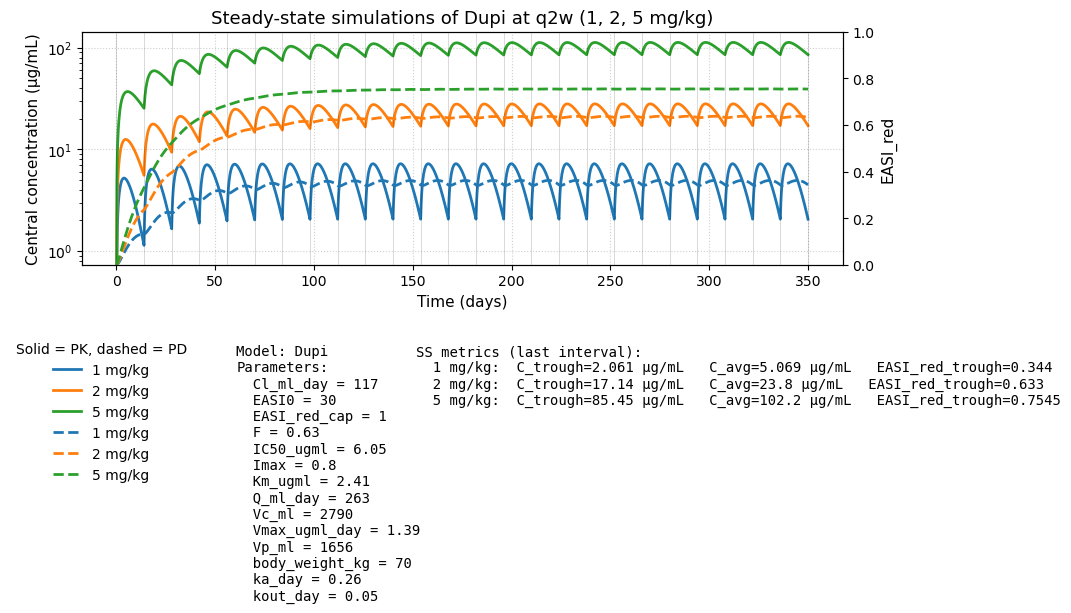

In [7]:
# -------------------------
# INPUT — edit only here
# -------------------------

# Show PK and/or PD
SHOW_PK = True
SHOW_PD = True

# Show parameter summary text block below the plot
SHOW_PARAM_SUMMARY = True

# Show metrics text block below the plot
SHOW_METRICS_SUMMARY = True

# Figure layout
FIG_WIDTH = 9
FIG_HEIGHT = 5

# PK axis settings
PK_LOG_SCALE = True
PK_AUTO = True
PK_YMIN = 1
PK_YMAX = 1000

# PD axis settings
PD_AUTO = False
PD_YMIN = 0
PD_YMAX = 1


# ------------------------------------------------------------
# FURTHER LAYOUT SETTINGS
# ------------------------------------------------------------
BOTTOM_MARGIN = 0.34

LEGEND_X = 0.1
LEGEND_Y = 0

PARAM_TEXT_X = 0.25
PARAM_TEXT_Y = 0.3

METRICS_TEXT_X = 0.45
METRICS_TEXT_Y = 0.3

TITLE_FONTSIZE = 13
LABEL_FONTSIZE = 11
TEXT_FONTSIZE = 10

PK_LINEWIDTH = 2.0
PD_LINEWIDTH = 2.0
DOSE_LINEWIDTH = 0.7


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def read_timecourse_from_h5(h5_path: Path):
    """
    Read timecourse data from a run.h5 file.

    Returns
    -------
    t : np.ndarray
        Time in days
    pk_vals : np.ndarray
        PK timecourse using the configured pk_key
    pd_vals : np.ndarray or None
        PD timecourse using the configured pd_key, if present
    pk_key : str
        Name of the PK variable stored in the file metadata
    pd_key : str or None
        Name of the PD variable stored in the file metadata, if available
    """
    with h5py.File(h5_path, "r") as f:
        pk_key = f.attrs.get("pk_key", "Central_ugml")
        pd_key = f.attrs.get("pd_key", None)

        # Prefer full timecourse if available
        if "t_days_full" in f and "derived_full" in f:
            t = f["t_days_full"][:]
            derived_group = f["derived_full"]
        else:
            t = f["t_days"][:]
            derived_group = f["derived"]

        pk_vals = derived_group[pk_key][:]
        pd_vals = derived_group[pd_key][:] if (pd_key and pd_key in derived_group) else None

    return t, pk_vals, pd_vals, pk_key, pd_key


def auc_trapz(t, y):
    """Trapezoidal AUC calculation."""
    return float(np.trapz(y, t))


def format_ss_summary(runs: list, cfg: dict):
    """
    Format steady-state summary metrics from the run summaries.
    """
    pd_key = cfg.get("outputs", {}).get("pd_key", None)
    lines = ["SS metrics (last interval):"]

    for r in sorted(runs, key=lambda x: float(x["dose_mgkg"])):
        summary = r["summary"]
        dose = float(r["dose_mgkg"])

        line = (
            f"  {dose:.4g} mg/kg:  "
            f"C_trough={summary.get('C_trough_ugml', float('nan')):.4g} µg/mL   "
            f"C_avg={summary.get('C_avg_ugml', float('nan')):.4g} µg/mL"
        )

        if pd_key is not None:
            pd_col = f"{pd_key}_trough"
            if pd_col in summary:
                line += f"   {pd_col}={summary[pd_col]:.4g}"

        lines.append(line)

    return "\n".join(lines)


def format_sd_summary(sd_metrics):
    """
    Format single-dose PK metrics calculated from the plotted trajectories.
    """
    lines = ["SD PK metrics:"]

    for metric in sorted(sd_metrics, key=lambda x: float(x["dose"])):
        lines.append(
            f"  {metric['dose']:.4g} mg/kg:  "
            f"AUC={metric['AUC']:.4g}   "
            f"Cmax={metric['Cmax']:.4g} µg/mL   "
            f"Tmax={metric['Tmax']:.4g} d"
        )

    return "\n".join(lines)


def format_param_summary(cfg, model_module, effective_params):
    """
    Create a readable text summary of the active model parameters.
    """
    lines = []
    lines.append(f"Model: {cfg['model']['name']}")
    lines.append("Parameters:")

    for key, value in sorted(effective_params.items()):
        if isinstance(value, float):
            lines.append(f"  {key} = {value:g}")
        else:
            lines.append(f"  {key} = {value}")

    if hasattr(model_module, "microconstants"):
        try:
            mcs = model_module.microconstants(effective_params)
            if mcs:
                lines.append("Microconstants:")
                for key, value in sorted(mcs.items()):
                    if isinstance(value, float):
                        lines.append(f"  {key} = {value:g}")
                    else:
                        lines.append(f"  {key} = {value}")
        except Exception as e:
            lines.append(f"Microconstants: error ({e})")

    return "\n".join(lines)


# ------------------------------------------------------------
# BASIC VALIDATION
# ------------------------------------------------------------
if not SHOW_PK and not SHOW_PD:
    raise ValueError("At least one of SHOW_PK or SHOW_PD must be True.")

if not runs:
    raise ValueError("`runs` is empty. Execute the simulation cell first.")


# ------------------------------------------------------------
# PREPARE FIGURE
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
ax2 = None  # PD axis will be created only if needed

ax1.set_xlabel("Time (days)", fontsize=LABEL_FONTSIZE)
ax1.grid(True, linestyle=":", alpha=0.6)

# PK axis setup
if SHOW_PK:
    ax1.set_ylabel("Central concentration (µg/mL)", fontsize=LABEL_FONTSIZE)
    if PK_LOG_SCALE:
        ax1.set_yscale("log")
    if not PK_AUTO:
        ax1.set_ylim(PK_YMIN, PK_YMAX)
else:
    ax1.set_ylabel("")


# ------------------------------------------------------------
# COLOR MAPPING
# ------------------------------------------------------------
# Same dose = same color for PK and PD
doses_sorted = sorted({float(r["dose_mgkg"]) for r in runs})
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
dose_to_color = {dose: prop_cycle[i % len(prop_cycle)] for i, dose in enumerate(doses_sorted)}

pk_handles = []
pd_handles = []
pd_present = False
sd_metrics = []


# ------------------------------------------------------------
# PLOT ALL RUNS
# ------------------------------------------------------------
for r in sorted(runs, key=lambda x: float(x["dose_mgkg"])):
    run_dir = r["run_dir"]
    h5_path = run_dir / "run.h5"

    if not h5_path.exists():
        raise FileNotFoundError(f"Missing run.h5 in:\n  {run_dir}")

    t, pk_vals, pd_vals, pk_key, pd_key = read_timecourse_from_h5(h5_path)

    dose = float(r["dose_mgkg"])
    color = dose_to_color[dose]

    # PK curve
    if SHOW_PK:
        ax1.plot(t, pk_vals, linewidth=PK_LINEWIDTH, color=color)
        pk_handles.append(
            mlines.Line2D([], [], color=color, lw=PK_LINEWIDTH, linestyle="-", label=f"{dose:g} mg/kg")
        )

    # PD curve
    if SHOW_PD and pd_vals is not None:
        pd_present = True

        if ax2 is None:
            ax2 = ax1.twinx()
            ax2.set_ylabel(pd_key or "PD", fontsize=LABEL_FONTSIZE)
            if not PD_AUTO:
                ax2.set_ylim(PD_YMIN, PD_YMAX)

        ax2.plot(t, pd_vals, linewidth=PD_LINEWIDTH, linestyle="--", color=color)

        pd_handles.append(
            mlines.Line2D([], [], color=color, lw=PD_LINEWIDTH, linestyle="--", label=f"{dose:g} mg/kg")
        )

    # SD metrics from PK
    if T_END_MODE == "SD" and SHOW_PK:
        AUC = auc_trapz(t, pk_vals)
        Cmax = float(np.max(pk_vals))
        Tmax = float(t[np.argmax(pk_vals)])
        sd_metrics.append({
            "dose": dose,
            "AUC": AUC,
            "Cmax": Cmax,
            "Tmax": Tmax,
        })


# ------------------------------------------------------------
# DOSE-TIME MARKERS FOR STEADY STATE
# ------------------------------------------------------------
if T_END_MODE == "SS" and len(runs) > 0:
    interval_weeks = int(runs[0].get("time_weeks", runs[0].get("interval_weeks", time_weeks)))
    iota_days = interval_weeks * 7
    dose_times = np.arange(0, n_doses_override * iota_days + 1e-9, iota_days)

    for td in dose_times:
        ax1.axvline(td, linewidth=DOSE_LINEWIDTH, alpha=0.15, color="k")


# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------
dose_text = ", ".join(f"{d:g}" for d in doses_sorted)

if T_END_MODE == "SS":
    title = f"Steady-state simulations of {MODEL} at q{time_weeks}w ({dose_text} mg/kg)"
else:
    title = f"Single-dose simulations of {MODEL} ({dose_text} mg/kg)"

ax1.set_title(title, fontsize=TITLE_FONTSIZE)


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
handles = []
legend_title = None

if SHOW_PK:
    handles.extend(pk_handles)

if SHOW_PD and pd_present:
    handles.extend(pd_handles)

if SHOW_PK and SHOW_PD and pd_present:
    legend_title = "Solid = PK, dashed = PD"

if handles:
    # Force ordering: PK first, then PD
    handles = pk_handles + pd_handles

    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(LEGEND_X, LEGEND_Y),
        ncol=1,  # <-- KEY CHANGE: vertical stacking
        frameon=False,
        title=legend_title,
    )

# ------------------------------------------------------------
# TEXT BLOCKS
# ------------------------------------------------------------
param_summary_text = format_param_summary(
    cfg=cfg,
    model_module=model_module,
    effective_params=effective_params,
)

if T_END_MODE == "SS":
    metrics_text = format_ss_summary(runs, cfg)
else:
    metrics_text = format_sd_summary(sd_metrics) if sd_metrics else "No SD PK metrics available."

if SHOW_PARAM_SUMMARY:
    fig.text(
        PARAM_TEXT_X, PARAM_TEXT_Y,
        param_summary_text,
        ha="left", va="top",
        fontsize=TEXT_FONTSIZE,
        family="monospace",
    )

if SHOW_METRICS_SUMMARY:
    fig.text(
        METRICS_TEXT_X, METRICS_TEXT_Y,
        metrics_text,
        ha="left", va="top",
        fontsize=TEXT_FONTSIZE,
        family="monospace",
    )


# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
# Store the most recently generated figure for optional saving in the next cell
latest_fig = fig

plt.tight_layout(rect=[0, BOTTOM_MARGIN, 1, 1])

plt.show()

## 4. Save most recent plot

This cell saves the most recently generated figure from cell 3.

### Behavior
- Saves `latest_fig` as a `.png`
- Save location:
  `.../results/timecourse_plots/<MODEL>`
- Existing files with the same name are overwritten

### File name
The exported file name includes:
- model name
- simulation mode
- dose range
- interval range

### Requirement
- Cell 3 must be run first so that `latest_fig` exists

In [10]:
# -------------------------
# SAVE SETTINGS
# -------------------------

# Resolution
save_dpi = 300

# -------------------------
# BASIC CHECK
# -------------------------

if "latest_fig" not in globals():
    raise RuntimeError("No plot found. Run cell 3 first to generate `latest_fig`.")

if latest_fig is None:
    raise RuntimeError("`latest_fig` is None. Run cell 3 first.")

# -------------------------
# SAVE PATH
# -------------------------

plot_dir = repo_root / "results" / "timecourse_plots" / MODEL
plot_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# BUILD FILE NAME
# -------------------------

png_name = (
    f"{MODEL}"
    f"_{T_END_MODE}" 
    f"_dose_{min(dose_mgkg)}_to_{max(dose_mgkg)}"
    f"_interval_{time_weeks}.png"
)

png_path = plot_dir / png_name


# -------------------------
# SAVE FIGURE
# -------------------------

# Overwrites existing file with same name
latest_fig.savefig(png_path, dpi=save_dpi, bbox_inches="tight")

print("Saved plot to:", png_path)

Saved plot to: C:\Users\LevinSchöpfer\Automation_main\results\timecourse_plots\Dupi\DupiSS_dose_1_to_5_interval_2.png
